In [9]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- Chargement des données ---
(x_train_raw, y_train_fine), (x_test_raw, y_test_fine) = cifar100.load_data(label_mode='fine')
(_, y_train_coarse), (_, y_test_coarse) = cifar100.load_data(label_mode='coarse')

print(f"x_train_raw: {x_train_raw.shape}, dtype={x_train_raw.dtype}, range=[{x_train_raw.min()}, {x_train_raw.max()}]")
print(f"x_test_raw:  {x_test_raw.shape}")

x_train_raw: (50000, 32, 32, 3), dtype=uint8, range=[0, 255]
x_test_raw:  (10000, 32, 32, 3)


In [10]:
# --- 1. Normalisation ---
# Option 1 : Simple /255 → pour CNN personnalisé (32x32)
x_train_simple = x_train_raw / 255.0
x_test_simple  = x_test_raw  / 255.0

# Option 2 : Normalisation ImageNet → pour MobileNetV2 / EfficientNet
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
x_train_imagenet = (x_train_raw / 255.0 - mean) / std
x_test_imagenet  = (x_test_raw  / 255.0 - mean) / std

print("Option 1 (simple)   — train range: [{:.3f}, {:.3f}]".format(x_train_simple.min(), x_train_simple.max()))
print("Option 2 (ImageNet) — train range: [{:.3f}, {:.3f}]".format(x_train_imagenet.min(), x_train_imagenet.max()))

Option 1 (simple)   — train range: [0.000, 1.000]
Option 2 (ImageNet) — train range: [-2.118, 2.640]


In [14]:
# --- 2. One-Hot Encoding des labels ---
y_train_fine_ohe   = to_categorical(y_train_fine,   num_classes=100)
y_test_fine_ohe    = to_categorical(y_test_fine,    num_classes=100)
y_train_coarse_ohe = to_categorical(y_train_coarse, num_classes=20)
y_test_coarse_ohe  = to_categorical(y_test_coarse,  num_classes=20)

print(f"y_train_fine_ohe:   {y_train_fine_ohe.shape}")    # (50000, 100)
print(f"y_test_fine_ohe:    {y_test_fine_ohe.shape}")     # (10000, 100)
print(f"y_train_coarse_ohe: {y_train_coarse_ohe.shape}")  # (50000, 20)
print(f"Exemple label fine[0]: classe {y_train_fine[0][0]} → vecteur one-hot (somme={y_train_fine_ohe[0].sum():.0f})")

y_train_fine_ohe:   (50000, 100)
y_test_fine_ohe:    (10000, 100)
y_train_coarse_ohe: (50000, 20)
Exemple label fine[0]: classe 19 → vecteur one-hot (somme=1)


In [ ]:
# --- 3. Data Augmentation (CRITIQUE : 500 images/classe seulement) ---

class RandomErasing(tf.keras.layers.Layer):
    def __init__(self, prob=0.5, sl=0.02, sh=0.2, r1=0.3, **kwargs):
        super().__init__(**kwargs)
        self.prob = prob   # probabilité d'appliquer l'effacement
        self.sl   = sl     # aire min du rectangle (fraction de l'image)
        self.sh   = sh     # aire max du rectangle
        self.r1   = r1     # ratio min hauteur/largeur

    def call(self, x, training=None):
        if not training:
            return x
        return tf.map_fn(self._erase_one, x)

    def _erase_one(self, img):
        # N'applique l'effacement qu'avec probabilité self.prob
        if tf.random.uniform(()) > self.prob:
            return img
        h, w, c = img.shape[0] or 32, img.shape[1] or 32, img.shape[2] or 3
        area = h * w
        for _ in range(10):   # 10 tentatives pour trouver un rectangle valide
            se = tf.random.uniform((), self.sl, self.sh) * area
            re = tf.random.uniform((), self.r1, 1.0 / self.r1)
            he = tf.cast(tf.math.round(tf.sqrt(se * re)), tf.int32)
            we = tf.cast(tf.math.round(tf.sqrt(se / re)), tf.int32)
            if he < h and we < w:
                x1 = tf.random.uniform((), 0, h - he, dtype=tf.int32)
                y1 = tf.random.uniform((), 0, w - we, dtype=tf.int32)
                # Bruit aléatoire dans [0, 1] pour le rectangle masqué
                noise = tf.random.uniform((he, we, c), 0, 1)
                # Construire le masque par padding + découpe
                pad = tf.pad(
                    noise,
                    [[x1, h - x1 - he], [y1, w - y1 - we], [0, 0]]
                )
                mask = tf.cast(tf.equal(pad, 0), tf.float32)
                return img * mask + pad * (1 - mask)
        return img

    def get_config(self):
        return {**super().get_config(), "prob": self.prob,
                "sl": self.sl, "sh": self.sh, "r1": self.r1}


# tf.keras.layers gère correctement les tenseurs float32 [0, 1]
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.055),                       # ±20°
    tf.keras.layers.RandomZoom(0.25),                            # ±25%
    tf.keras.layers.RandomTranslation(0.15, 0.15),               # ±15%
    tf.keras.layers.RandomBrightness(0.2, value_range=(0, 1)),   # ±20%
    RandomErasing(prob=0.5, sl=0.02, sh=0.2),                    # Cutout
], name="data_augmentation")

print("Pipeline d'augmentation (tf.keras.layers) :")
data_augmentation.summary()

Pipeline d'augmentation (tf.keras.layers) :


Model: "data_augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_2 (RandomFlip)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_2               │ ?                      │   0 (unbuilt) │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_2 (RandomZoom)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_2            │ ?                      │   0 (unbuilt) │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness_2             │ ?                      │   0 (unbuilt) │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_erasing (RandomErasing)  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

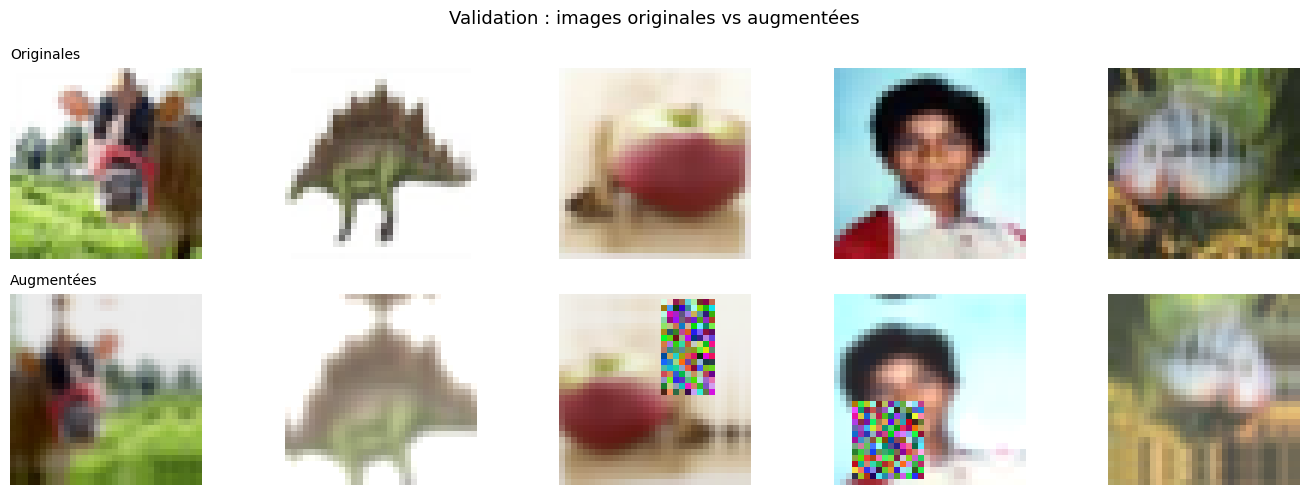

 Labels inchangés après augmentation
 Range images originales  : [0.000, 1.000]
 Range images augmentées  : [0.000, 1.000]
 Valeurs toujours dans [0, 1]


In [19]:
# --- 4. Validation de l'augmentation ---
n_samples = 5
sample_imgs   = tf.constant(x_train_simple[:n_samples], dtype=tf.float32)
sample_labels = y_train_fine[:n_samples]

fig, axes = plt.subplots(2, n_samples, figsize=(14, 5))

for i in range(n_samples):
    axes[0, i].imshow(np.clip(sample_imgs[i].numpy(), 0, 1))
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Originales', fontsize=10, loc='left')

aug_imgs = data_augmentation(sample_imgs, training=True).numpy()

for i in range(n_samples):
    axes[1, i].imshow(np.clip(aug_imgs[i], 0, 1))
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Augmentées', fontsize=10, loc='left')

fig.suptitle("Validation : images originales vs augmentées", fontsize=13)
plt.tight_layout()
plt.show()

# Vérification 1 : labels inchangés
# L'augmentation ne doit PAS modifier les labels (transformation d'image pure)
aug_labels = sample_labels  # les layers keras ne touchent pas aux labels
assert np.array_equal(sample_labels, aug_labels), "Labels modifiés par l'augmentation !"
print(" Labels inchangés après augmentation")

# Vérification 2 : plage de valeurs cohérente
print(f" Range images originales  : [{sample_imgs.numpy().min():.3f}, {sample_imgs.numpy().max():.3f}]")
print(f" Range images augmentées  : [{aug_imgs.min():.3f}, {aug_imgs.max():.3f}]")
assert aug_imgs.min() >= 0.0 and aug_imgs.max() <= 1.0, "Valeurs hors [0, 1] après augmentation !"
print(" Valeurs toujours dans [0, 1]")